# ✨ Proyecto Análisis de Datos No Estructurados 📖

## 🏆 Proyecto: Aplicacion de *topic modeling* utilizando LDA a documentos relacionados a fallas de una empresa de energía

📅 **Desarrollado por:** Bayron Andrés Guamá Erira


### Contexto de los datos

Los datos originales corresponden a una base de datos de fallas e indisponibilidades de una empresa de energía, esta tiene más de 3000 filas y más de 20 columnas.

Primero identificamos la columna objetivo de este conjunto de datos y la extraimos, esta columna se llama "Descripción" la cual contiene informacion registrada de forma manual por los operadores o técnicos de las diferentes centrales.


###Objetivo
Mediante la aplicación de topic modeling realizar un agrupamiento de textos en diferetntes clusters para obtener insights de datos que den señales sobre algún proceso, equipo  o problema recurrente.

## 1. Instalacion de librerias, importacion y cargue de datos

In [ ]:
import warnings

warnings.filterwarnings("ignore")#ignoar warning para no contaminar el notebook

In [ ]:
#instalación de paquetes
!pip install gensim
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 38.1 MB/s eta 0:00:00


In [ ]:
#Importación de las librerias necesarias
import warnings
import re
import nltk
import gensim
import pprint
from gensim import corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel
import pyLDAvis.gensim_models
import pyLDAvis.gensim_models as gensimvis

warnings.filterwarnings("ignore")#ignoar warning para no contaminar el notebook
# Instalar y/o importar nltk para usar las stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords

# Definimos nuestras stopwords en Español
stop_words = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# !pip install pandas

import pandas as pd

try:

  #cargamos los datos, que están en formato excel
    df = pd.read_excel('/content/datos indisponibilidades.xlsx')

    # Seleccionamos textos en columna 'Descripcion'
    documents = df['Descripcion'].astype(str).tolist()
    print(f"Se cargaron {len(documents)} documentos desde el archivo Excel.")

except FileNotFoundError:
    print("Error: El archivo 'tu_archivo.xlsx' no se encontró. Asegúrate de que esté en la ruta correcta.")
except KeyError:
    print("Error: La columna 'nombre_de_la_columna_de_texto' no se encontró en el archivo Excel.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo Excel: {e}")


Se cargaron 3156 documentos desde el archivo Excel.


In [ ]:
# mostrar los primeros documentos para verificar
print(documents[:5])

['pruebas de automatización', 'MANTENIMIENTO CORRECTIVO', 'Unidad indisponible para revisión sistema hidraúlico regulador de velocidad', 'Revision por disparo de unidad por alta temperatura estator fase A ', 'revisión tanque de agua refrigeración']


## 2. Preprocesamiento: realizamos tokenización y eliminación de stopwords

In [ ]:
texts = []
for doc in documents:
    tokens = doc.lower().split()
    tokens = [re.sub(r'[^\w\s]', '', t) for t in tokens]
    tokens = [t for t in tokens if t]
    # Filtra las stopwords
    filtered_tokens = [t for t in tokens if t not in stop_words]
    texts.append(filtered_tokens)

# Crear diccionario (asocia IDs numéricos a las palabras)
dictionary = corpora.Dictionary(texts)

# Convertir documentos a la matriz TDM de “bolsa de palabras”
corpus = [dictionary.doc2bow(text) for text in texts]

## 3.1 Definición e instancia del modelo LDA para topic modeling

In [ ]:
# Definir e instanciar el modelo LDA
num_topics = 15  # número de temas deseados
lda_model = LdaModel(corpus=corpus,
                     id2word=dictionary,
                     num_topics=num_topics,
                     random_state=42,
                     passes=100,
                     alpha='auto',
                     per_word_topics=True)

# Ver los temas obtenidos
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}:\n{topic}\n")

doc_lda = lda_model[corpus]

Topic 0:
0.051*"salto" + 0.046*"paraíso" + 0.033*"2" + 0.027*"realizan" + 0.025*"ii" + 0.021*"linea" + 0.020*"cambio" + 0.019*"proteccion" + 0.017*"rele" + 0.017*"disparo"

Topic 1:
0.152*"pruebas" + 0.040*"regulador" + 0.038*"protecciones" + 0.034*"revisión" + 0.033*"parada" + 0.031*"cargabilidad" + 0.025*"velocidad" + 0.022*"protección" + 0.017*"carga" + 0.017*"tensión"

Topic 2:
0.118*"sistema" + 0.091*"revisión" + 0.079*"control" + 0.073*"excitación" + 0.037*"falla" + 0.030*"regulador" + 0.026*"bombas" + 0.025*"comunicaciones" + 0.020*"velocidad" + 0.018*"prueba"

Topic 3:
0.093*"interruptor" + 0.088*"potencia" + 0.038*"auxiliares" + 0.034*"cambio" + 0.033*"indisponible" + 0.032*"falla" + 0.031*"paraiso" + 0.026*"unidad" + 0.018*"1" + 0.017*"transformador"

Topic 4:
0.086*"pruebas" + 0.062*"factor" + 0.062*"conversión" + 0.045*"redespacho" + 0.042*"solicita" + 0.035*"periodos" + 0.034*"rotor" + 0.025*"percentil" + 0.016*"xm" + 0.016*"50"

Topic 5:
0.316*"mantenimiento" + 0.116*"pre

##3.2 Ajuste de Coherence Score
Hemos realizado un proceso iterativo buscando con el modelo LDA:

1.   cantidad de temas con el cual el puntaje de coherencia es mayor
2.   numero de iteraciones con el cual el puntaje de coherencia es mayor

los resultados de esto se muestran en la imagen:

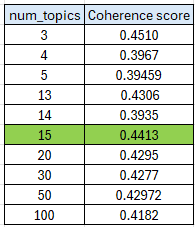


Observamos que el mejor valor se logra con 3 temas. Sin embargo a nuestro criterio ese es un numero bajo para poder encontrar señales e insights importantes para la empresa. Partimos del hecho de que entre más grupos tengamos, mejor podremos identificar agrupamientos relevantes y que estén relacionados entre los temas. Decidimos encontrar más grupos sin reducir demasiado el valor de coherencia y al final nos quedamos con 15 temas.

Luego probamos con varias iteraciones para aumentar el valor del coherence encontrando como mejor opcion un número de 100 iteraciones, como se muestra en la siguiete imagen:

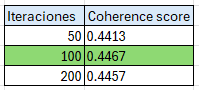

In [ ]:
# Compute Coherence Score
coherence_model_lda = CoherenceModel(
    model=lda_model,           # Your trained LDA model
    texts=texts,               # Tokenized texts
    dictionary=dictionary,     # Gensim dictionary
    coherence='c_v'            # Coherence measure
)

coherence_lda = coherence_model_lda.get_coherence()
print(f"Coherence Score (c_v): {coherence_lda}")

Coherence Score (c_v): 0.44674918117825885




##4. Representación visual de los resultados de la aplicación del modelo


In [ ]:
pyLDAvis.enable_notebook()  # Habilita la visualización dentro de la notebook
vis_data = gensimvis.prepare(lda_model, corpus, dictionary, mds='tsne') # mds = ['tsne', 'pcoa', 'mmds']
pyLDAvis.display(vis_data)  # Renderiza la visualización interactiva

### Interpretación y Resultados de la visualización:


Las burbujas están bien separadas lo que nos indica que el modelo encontró grupos temáticos diferenciados.

El tema 1 es el dominante en el corpus, los temas 7 y 3 estan cercanos a este lo que indica que puede haber relacion entre estos temas, el resto de temas sí están bien separados.

Algunos resultados del análisis de las barras:


*  Por ejemplo el tema 1 nos ayuda a identificar información importante sobre particularidades en las fallas presentadas en las centrales como Motivos de las fallas: disparos de las protecciones, problemas en regulador, valvulas, inyector, aguja, velocidad, arranque, protección 86m.  
*   El tema 2 nos muestra otro tipo de caracteristicas como: temperatura, cojinetes, sistema de refrigferación.




